In [ ]:
### Assignment 1 - Bonus B: Sex Prediction from DNA Methylation 

%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.functions import (
    load_data,
    split_stratified_data,
    build_num_preprocessor,
    classification_model_evaluate_bootstrapping,
    build_classification_results_table, search_best_K_classif
)

from mrmr import mrmr_classif                    

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
)
from scipy.stats import pointbiserialr           # for the top 20 sex-discriminative CpGs               

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# load data
df_dev = load_data('../data/development_data.csv')
df_eval = load_data('../data/evaluation_data.csv')

cpg_features = [col for col in df_dev.columns if col.startswith('cg')]

X_cpg = df_dev[cpg_features]
y_sex = df_dev['sex'].map({'M': 1, 'F': 0})

# Evaluation set
X_eval     = df_eval[cpg_features]
y_eval_sex = df_eval['sex'].map({'M': 1, 'F': 0})

print("Class distribution (dev):\n", y_sex.value_counts())
print("Class distribution (eval):\n", y_eval_sex.value_counts())

# Train/val split — stratified by sex
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_cpg, y_sex, test_size=0.2, random_state=42, stratify=y_sex
)

print(f"\nTraining set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Evaluation set: {X_eval.shape}")

Class distribution (dev):
 sex
1    232
0    224
Name: count, dtype: int64
Class distribution (eval):
 sex
0    58
1    42
Name: count, dtype: int64

Training set:   (364, 1000)
Validation set: (92, 1000)
Evaluation set: (100, 1000)


100%|██████████| 10/10 [00:01<00:00,  8.68it/s]


K=  10 → Val F1: 0.8511


100%|██████████| 20/20 [00:02<00:00,  8.66it/s]


K=  20 → Val F1: 0.8542


100%|██████████| 50/50 [00:05<00:00,  8.35it/s]


...

K= 200 → Val F1: 0.9684


100%|██████████| 250/250 [00:29<00:00,  8.61it/s]


K= 250 → Val F1: 0.9485


100%|██████████| 300/300 [00:34<00:00,  8.72it/s]


K= 300 → Val F1: 0.9474


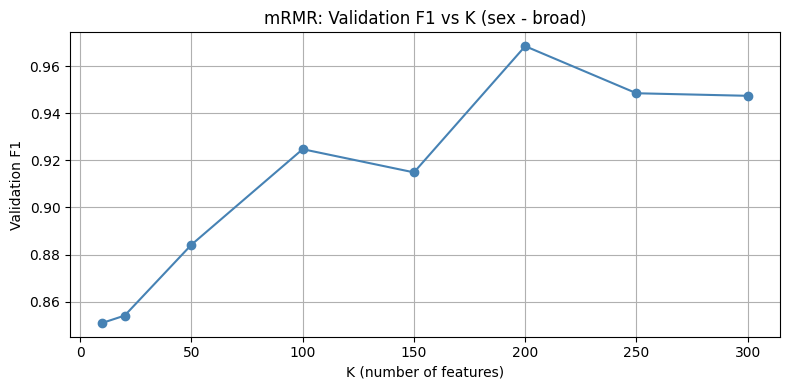


Best K (max F1): 200


In [ ]:
# mRMR feature selection for sex prediction

# preprocessing
num_preprocessor_sex = build_num_preprocessor()
X_train_preprocessed = num_preprocessor_sex.fit_transform(X_train)
X_val_preprocessed   = num_preprocessor_sex.transform(X_val)

# DataFrames for mRMR
X_train_df = pd.DataFrame(X_train_preprocessed, columns=cpg_features, index=X_train.index)
X_val_df   = pd.DataFrame(X_val_preprocessed,   columns=cpg_features, index=X_val.index)

# K search for sex mRMR — using LogisticRegression as proxy model

_, best_K_sex = search_best_K_classif(
    X_train_df, y_train, X_val_df, y_val,
    model=LogisticRegression(random_state=42),
    K_values=[10, 20, 50, 100, 150, 200, 250, 300],
    save_path='../figures/mrmr_sex_K_broad.png',
    title_suffix='(sex - broad)'
)

F1 is used as the selection metric for K instead of accuracy, as it accounts for both precision and recall, making it more robust for evaluating classification performance even with slight class imbalance (232M/224F)


100%|██████████| 180/180 [00:21<00:00,  8.38it/s]


K= 180 → Val F1: 0.9485


100%|██████████| 185/185 [00:21<00:00,  8.47it/s]


K= 185 → Val F1: 0.9388


100%|██████████| 190/190 [00:21<00:00,  8.90it/s]


...

K= 205 → Val F1: 0.9684


100%|██████████| 210/210 [00:24<00:00,  8.72it/s]


K= 210 → Val F1: 0.9684


100%|██████████| 215/215 [00:24<00:00,  8.63it/s]


K= 215 → Val F1: 0.9583


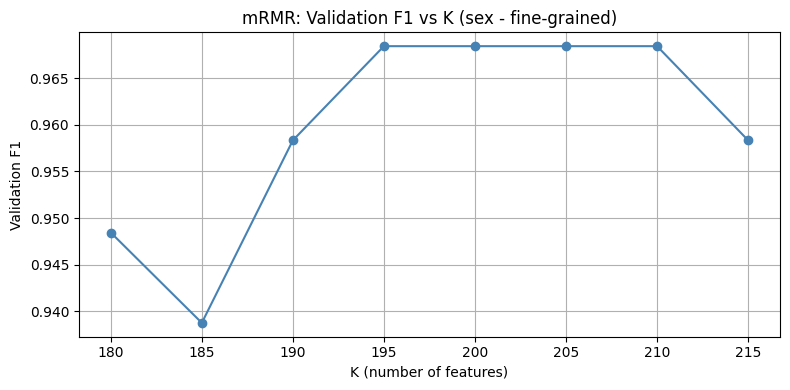


Best K (max F1): 195


In [6]:
# fine-grained search
_, best_K_sex = search_best_K_classif(
    X_train_df, y_train, X_val_df, y_val,
    model=LogisticRegression(random_state=42),
    K_values=range(180, 220, 5),
    save_path='../figures/mrmr_sex_K_fine.png',
    title_suffix='(sex - fine-grained)'
)

100%|██████████| 191/191 [00:22<00:00,  8.45it/s]


K= 191 → Val F1: 0.9583


100%|██████████| 192/192 [00:22<00:00,  8.55it/s]


K= 192 → Val F1: 0.9684


100%|██████████| 193/193 [00:21<00:00,  8.95it/s]


K= 193 → Val F1: 0.9684


100%|██████████| 194/194 [00:20<00:00,  9.60it/s]


K= 194 → Val F1: 0.9684


100%|██████████| 195/195 [00:21<00:00,  9.13it/s]


K= 195 → Val F1: 0.9684


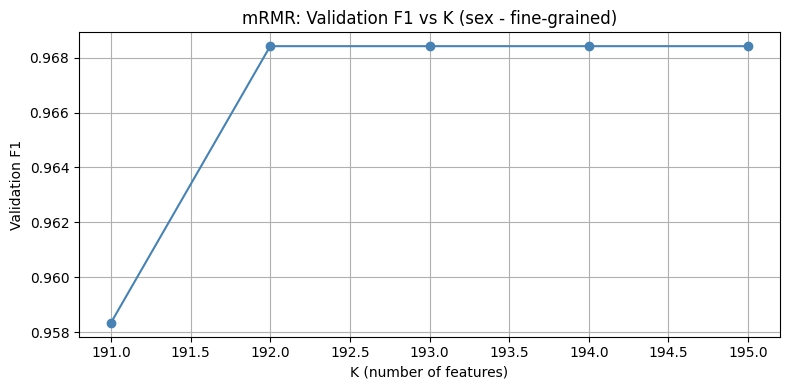


Best K (max F1): 192


In [8]:
#even more detailed search
_, best_K_sex = search_best_K_classif(
    X_train_df, y_train, X_val_df, y_val,
    model=LogisticRegression(random_state=42),
    K_values=range(191, 196, 1),
    save_path='../figures/mrmr_sex_K_detailed.png',
    title_suffix='(sex - fine-grained)'
)

In [9]:
best_K_sex = 192
print(f"Selected K={best_K_sex} by Occam's Razor: minimum features achieving max F1=0.9684")

# Final mRMR feature selection for sex
cpg_sex_features = mrmr_classif(X=X_train_df, y=y_train, K=best_K_sex)
print(f"Selected {len(cpg_sex_features)} features for sex prediction")

Selected K=192 by Occam's Razor: minimum features achieving max F1=0.9684


100%|██████████| 192/192 [00:22<00:00,  8.45it/s]

Selected 192 features for sex prediction


In [10]:
# we have to obtain again the mrmr cpg features for age (same as Task 3)
from mrmr import mrmr_regression

y_age = df_dev['age']

# exact same split as Task 3
X_train_age, _, y_train_age, _ = split_stratified_data(X_cpg, y_age, n_bins=5, test_size=0.2, random_state=42)

# exact same preprocessing as Task 3
num_preprocessor_age = build_num_preprocessor()
X_train_age_preprocessed = num_preprocessor_age.fit_transform(X_train_age)
X_train_age_df = pd.DataFrame(
    X_train_age_preprocessed,
    columns=cpg_features,
    index=X_train_age.index
)

# mRMR for age (K=197, same as Task 3)
cpg_age_features = mrmr_regression(X=X_train_age_df, y=y_train_age, K=197)
print(f"Age mRMR features: {len(cpg_age_features)}")

100%|██████████| 197/197 [00:23<00:00,  8.55it/s]

Age mRMR features: 197


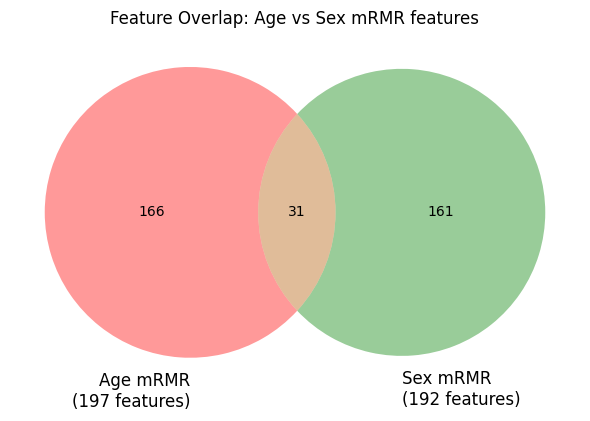

Common features:  31
Only in Age:      166
Only in Sex:      161
Overlap %:        8.7%


In [ ]:
# intersection of the sex and age cpg feature sets

from matplotlib_venn import venn2

age_set = set(cpg_age_features) 
sex_set = set(cpg_sex_features)

plt.figure(figsize=(6, 6))
venn2(
    [age_set, sex_set],
    set_labels=(
        f'Age mRMR\n({len(age_set)} features)',
        f'Sex mRMR\n({len(sex_set)} features)'
    )
)
plt.title('Feature Overlap: Age vs Sex mRMR features')
plt.tight_layout()
plt.savefig('../figures/venn_age_vs_sex.png', dpi=150, bbox_inches='tight')
plt.show()

overlap = age_set & sex_set
print(f"Common features:  {len(overlap)}")
print(f"Only in Age:      {len(age_set - sex_set)}")
print(f"Only in Sex:      {len(sex_set - age_set)}")
print(f"Overlap %:        {len(overlap)/len(age_set | sex_set)*100:.1f}%")

In [13]:
# classification models 
# Linear Regression and Gaussian Naive Bayes

# training on the sex mRMR feature set (K=192)
X_train_sex_features = X_train_df[cpg_sex_features]

# Logistic Regression
lr_pipe = Pipeline([
    ('model', LogisticRegression(random_state=42))
])
lr_pipe.fit(X_train_sex_features, y_train)

# Gaussian Naive Bayes
gnb_pipe = Pipeline([
    ('model', GaussianNB())
])
gnb_pipe.fit(X_train_sex_features, y_train)

# Predictions on evaluation set
# Note: X_eval needs to be preprocessed with the same preprocessor
X_eval_preprocessed = num_preprocessor_sex.transform(X_eval[cpg_features])
X_eval_df = pd.DataFrame(X_eval_preprocessed, columns=cpg_features, index=X_eval.index)
X_eval_sex_features = X_eval_df[cpg_sex_features]

y_pred_lr  = lr_pipe.predict(X_eval_sex_features)
y_prob_lr  = lr_pipe.predict_proba(X_eval_sex_features)[:, 1]

y_pred_gnb = gnb_pipe.predict(X_eval_sex_features)
y_prob_gnb = gnb_pipe.predict_proba(X_eval_sex_features)[:, 1]


In [14]:
# Bootstrap evaluation on evaluation set
lr_results,  lr_dict  = classification_model_evaluate_bootstrapping(
    y_eval_sex, y_pred_lr,  y_prob_lr,  n_bootstraps=1000, random_state=42
)
gnb_results, gnb_dict = classification_model_evaluate_bootstrapping(
    y_eval_sex, y_pred_gnb, y_prob_gnb, n_bootstraps=1000, random_state=42
)

# Results table
class_table = build_classification_results_table({
    'Logistic Regression': lr_results,
    'Gaussian NB':         gnb_results,
})

display(class_table)

,Accuracy (mean),Accuracy (95% CI),F1 (mean),F1 (95% CI),MCC (mean),MCC (95% CI),ROC-AUC (mean),ROC-AUC (95% CI),PR-AUC (mean),PR-AUC (95% CI)
Model,,,,,,,,,,
Logistic Regression,0.9305,"[0.8800, 0.9800]",0.9149,"[0.8485, 0.9744]",0.8567,"[0.7473, 0.9583]",0.9606,"[0.9098, 0.9976]",0.9674,"[0.9245, 0.9967]"
Gaussian NB,0.6896,"[0.6000, 0.7800]",0.6134,"[0.4810, 0.7340]",0.3566,"[0.1710, 0.5383]",0.7613,"[0.6632, 0.8547]",0.6337,"[0.4912, 0.7860]"


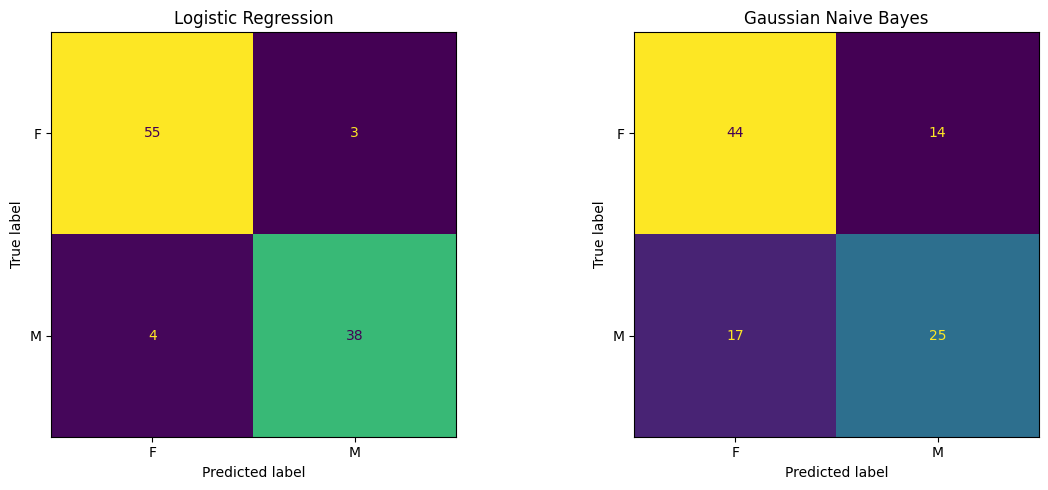

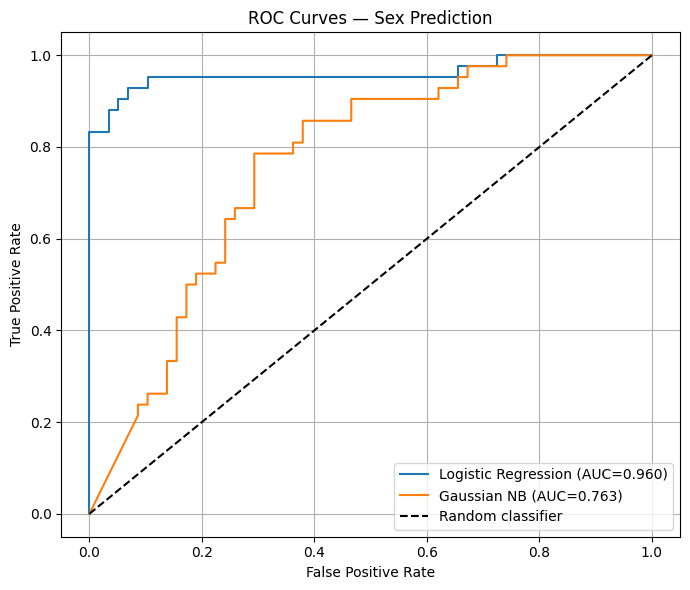

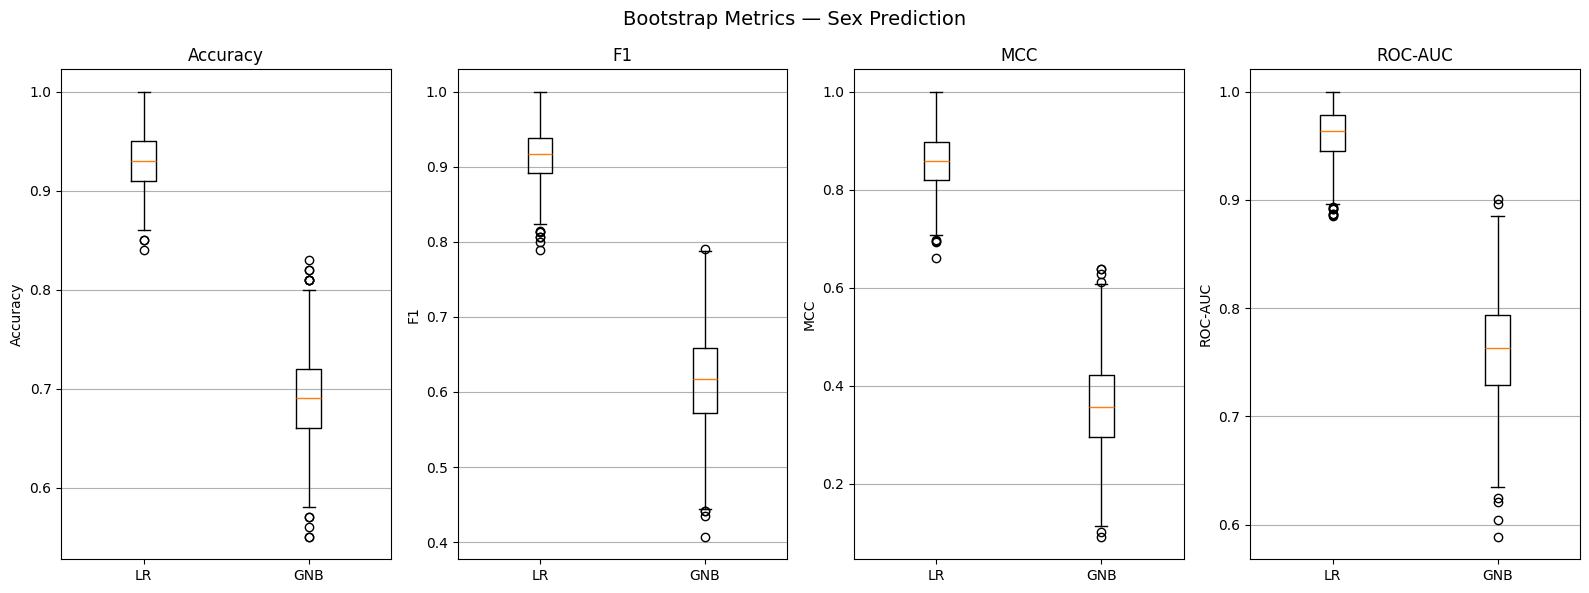

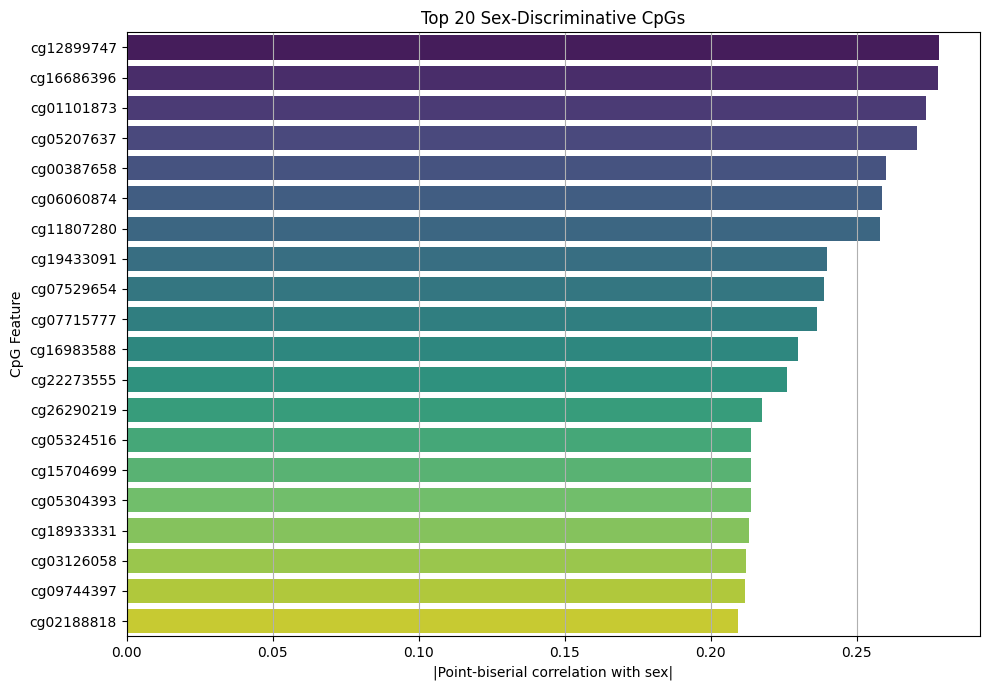

In [15]:
# --- 1. Confusion Matrices ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

cm_lr  = confusion_matrix(y_eval_sex, y_pred_lr)
cm_gnb = confusion_matrix(y_eval_sex, y_pred_gnb)

ConfusionMatrixDisplay(cm_lr,  display_labels=['F', 'M']).plot(ax=ax1, colorbar=False)
ConfusionMatrixDisplay(cm_gnb, display_labels=['F', 'M']).plot(ax=ax2, colorbar=False)

ax1.set_title('Logistic Regression')
ax2.set_title('Gaussian Naive Bayes')
plt.tight_layout()
plt.savefig('../figures/confusion_matrices_sex.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 2. ROC Curves ---
fpr_lr,  tpr_lr,  _ = roc_curve(y_eval_sex, y_prob_lr)
fpr_gnb, tpr_gnb, _ = roc_curve(y_eval_sex, y_prob_gnb)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr,  tpr_lr,  label=f'Logistic Regression (AUC={roc_auc_score(y_eval_sex, y_prob_lr):.3f})')
plt.plot(fpr_gnb, tpr_gnb, label=f'Gaussian NB (AUC={roc_auc_score(y_eval_sex, y_prob_gnb):.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Sex Prediction')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../figures/roc_curves_sex.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 3. Bootstrap Boxplots (all 4 metrics) ---
metrics = ['accuracy', 'f1_score', 'mcc', 'roc_auc']
metric_labels = ['Accuracy', 'F1', 'MCC', 'ROC-AUC']

fig, axes = plt.subplots(1, 4, figsize=(16, 6))

for ax, metric, label in zip(axes, metrics, metric_labels):
    data = [lr_dict[metric], gnb_dict[metric]]
    ax.boxplot(data, labels=['LR', 'GNB'])
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.grid(axis='y')

plt.suptitle('Bootstrap Metrics — Sex Prediction', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/classification_boxplots_sex.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 4. Top 20 sex-discriminative CpGs by |point-biserial r| ---
pb_scores = {}
for feature in cpg_sex_features:
    corr, _ = pointbiserialr(y_train, X_train_df[feature])
    pb_scores[feature] = abs(corr)

top20_df = pd.DataFrame({
    'Feature': list(pb_scores.keys()),
    '|Point-biserial r|': list(pb_scores.values())
}).sort_values('|Point-biserial r|', ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(x='|Point-biserial r|', y='Feature', data=top20_df, palette='viridis')
plt.xlabel('|Point-biserial correlation with sex|')
plt.ylabel('CpG Feature')
plt.title('Top 20 Sex-Discriminative CpGs')
plt.grid(axis='x')
plt.tight_layout()
plt.savefig('../figures/top20_sex_cpgs.png', dpi=150, bbox_inches='tight')
plt.show()

## Discussion: Logistic Regression vs Gaussian Naive Bayes

Logistic Regression vastly outperforms Gaussian Naive Bayes on all metrics 
(Accuracy: 0.931 vs 0.690, F1: 0.915 vs 0.613, ROC-AUC: 0.960 vs 0.763).
This large performance gap can be explained by two fundamental limitations of GNB 
on this dataset:

**1. Feature independence assumption violated**
Gaussian Naive Bayes assumes that all features are conditionally independent given 
the class label. However, CpG methylation sites are strongly correlated — especially 
X-linked CpGs which are co-regulated by the same X-inactivation mechanism. This 
violation of the independence assumption severely degrades GNB performance.

**2. Gaussian distribution assumption violated**
GNB assumes that each feature follows a Gaussian distribution within each class. 
However, DNA methylation beta values are often bimodal — clustering near 0 
(unmethylated) or 1 (fully methylated) — which is far from Gaussian, particularly 
for the sex-discriminative X-linked CpGs.

**Logistic Regression**, being a discriminative model, makes no assumptions about 
the feature distribution. It directly learns the decision boundary between F and M, 
effectively exploiting the strong and concentrated X-inactivation signal. The 
confusion matrix confirms this: LR misclassifies only 7/100 samples (3F→M, 4M→F), 
while GNB misclassifies 31/100 (14F→M, 17M→F).

The low overlap (8.7%) between age and sex mRMR features confirms that the two 
biological signals are largely independent — methylation patterns driving ageing 
are distinct from those driven by X-inactivation.